In [249]:
print("Hello, Jupyter!")


Hello, Jupyter!


In [250]:
!pip install seaborn


In [251]:
# Import packages
import numpy as np
import pandas as pd
# from PIL import ImageFont, ImageDraw, Image
import seaborn as sns # For Data Visualization
import matplotlib.pyplot as plt # Necessary module for plotting purpose
# plt.rcParams["patch.force_edgecolor"] = True
%matplotlib inline

# from plotly.offline import init_notebook_mode, iplot
# init_notebook_mode(connected=True)
# import plotly.graph_objs as go

import warnings
warnings.filterwarnings("ignore");

In [252]:


dataset = pd.read_csv(r"C:\Users\Vidushi\Downloads\laptop_price.csv", encoding="latin1")

In [253]:
dataset.sample(5)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1231,1249,Razer,Blade Pro,Gaming,14.0,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,1TB SSD,Nvidia GeForce GTX 1060,Windows 10,1.95kg,3499.0
390,396,Asus,Rog GL753VD-GC042T,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,1TB HDD,Nvidia GeForce GTX 1050,Windows 10,3kg,1039.0
644,652,Acer,Extensa EX2540,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 10,2.4kg,450.0
510,517,Dell,XPS 13,Ultrabook,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,128GB SSD,Intel HD Graphics 620,Windows 10,1.29kg,899.0
1084,1099,Dell,Vostro 3568,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.18kg,750.0


In [254]:
print('DATAFRAME SHAPE: ',dataset.shape)

DATAFRAME SHAPE:  (1303, 13)


In [255]:
dataset.drop("laptop_ID", axis=1, inplace=True)

In [256]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   Product           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price_euros       1303 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [257]:
dataset.isnull().sum()

Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [258]:
dataset.duplicated().sum()

np.int64(28)

In [259]:
# Getting categorical and numerical feature

cat_features = dataset.select_dtypes(include = 'object').columns
# alternate way : [feature for feature in df.columns if df[feature].dtypes == 'object']
num_features = dataset.select_dtypes(include = ['int32','int64','float32','float64']).columns
# alternate way : [feature for feature in df.columns if df[feature].dtypes != 'object']

In [260]:
cat_features

Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [261]:
# Print Numerical features

num_features

Index(['Inches', 'Price_euros'], dtype='object')

In [262]:

dataset['Company'].unique()

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

In [263]:
# Function to get unique values present in cols

def uniqueValues(feature):

    print(f'Unique values in {feature} is : {dataset[feature].unique()}')

for feature in cat_features:
    uniqueValues(feature)
    print('\n')
    print('-'*100)

Unique values in Company is : ['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']


----------------------------------------------------------------------------------------------------
Unique values in Product is : ['MacBook Pro' 'Macbook Air' '250 G6' 'Aspire 3' 'ZenBook UX430UN'
 'Swift 3' 'Inspiron 3567' 'MacBook 12"' 'IdeaPad 320-15IKB' 'XPS 13'
 'Vivobook E200HA' 'Legion Y520-15IKBN' '255 G6' 'Inspiron 5379'
 '15-BS101nv (i7-8550U/8GB/256GB/FHD/W10)' 'MacBook Air' 'Inspiron 5570'
 'Latitude 5590' 'ProBook 470' 'LapBook 15.6"'
 'E402WA-GA010T (E2-6110/2GB/32GB/W10)'
 '17-ak001nv (A6-9220/4GB/500GB/Radeon' 'IdeaPad 120S-14IAP'
 'Inspiron 5770' 'ProBook 450' 'X540UA-DM186 (i3-6006U/4GB/1TB/FHD/Linux)'
 'Inspiron 7577' 'X542UQ-GO005 (i5-7200U/8GB/1TB/GeForce'
 'Aspire A515-51G' 'Inspiron 7773' 'IdeaPad 320-15ISK' 'Rog Strix'
 'X751NV-TY001T (N4200/4GB/1TB/GeForce' 'Yoga Book' '

In [264]:
# Top 5 valuse/sample of dataframe

dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [265]:
# Let's start with feature 'RAM' and 'Weight' : from the observations if we remove GB and kg the easialy can be converted into int.

dataset['Ram'] = dataset['Ram'].str.replace('GB','').astype('int32')

dataset['Weight'] = dataset['Weight'].str.replace('kg','').astype('float32')

In [266]:
dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


In [267]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   Product           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   int32  
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   float32
 11  Price_euros       1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(8)
memory usage: 112.1+ KB


In [268]:
dataset = dataset.convert_dtypes()

In [269]:
# In the Ram column Ram is in GB and In weight column weight in KG 
# So, Rename the 'Ram' -- 'Ram_GB' and 'Weight' -- 'Weight_Kg'
dataset.rename(columns = {'Ram':'Ram_GB','Weight':'Weight_KG'}, inplace = True)

dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6


In [270]:
dataset.describe()

,Inches,Ram_GB,Weight_KG,Price_euros
count,1303.0,1303.0,1303.0,1303.0
mean,15.017191,8.382195,2.038734,1123.686992
std,1.426304,5.084665,0.665475,699.009043
min,10.1,2.0,0.69,174.0
25%,14.0,4.0,1.5,599.0
50%,15.6,8.0,2.04,977.0
75%,15.6,8.0,2.3,1487.88
max,18.4,64.0,4.7,6099.0


In [271]:
dataset.describe(include='all')

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros
count,1303,1303,1303,1303.0,1303,1303,1303.0,1303,1303,1303,1303.0,1303.0
unique,19,618,6,<NA>,40,118,<NA>,39,110,9,<NA>,<NA>
top,Dell,XPS 13,Notebook,<NA>,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,<NA>,256GB SSD,Intel HD Graphics 620,Windows 10,<NA>,<NA>
freq,297,30,727,<NA>,507,190,<NA>,412,281,1072,<NA>,<NA>
mean,NaN,NaN,NaN,15.017191,NaN,NaN,8.382195,NaN,NaN,NaN,2.038734,1123.686992
std,NaN,NaN,NaN,1.426304,NaN,NaN,5.084665,NaN,NaN,NaN,0.665475,699.009043
min,NaN,NaN,NaN,10.1,NaN,NaN,2.0,NaN,NaN,NaN,0.69,174.0
25%,NaN,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,NaN,1.5,599.0
50%,NaN,NaN,NaN,15.6,NaN,NaN,8.0,NaN,NaN,NaN,2.04,977.0
75%,NaN,NaN,NaN,15.6,NaN,NaN,8.0,NaN,NaN,NaN,2.3,1487.88


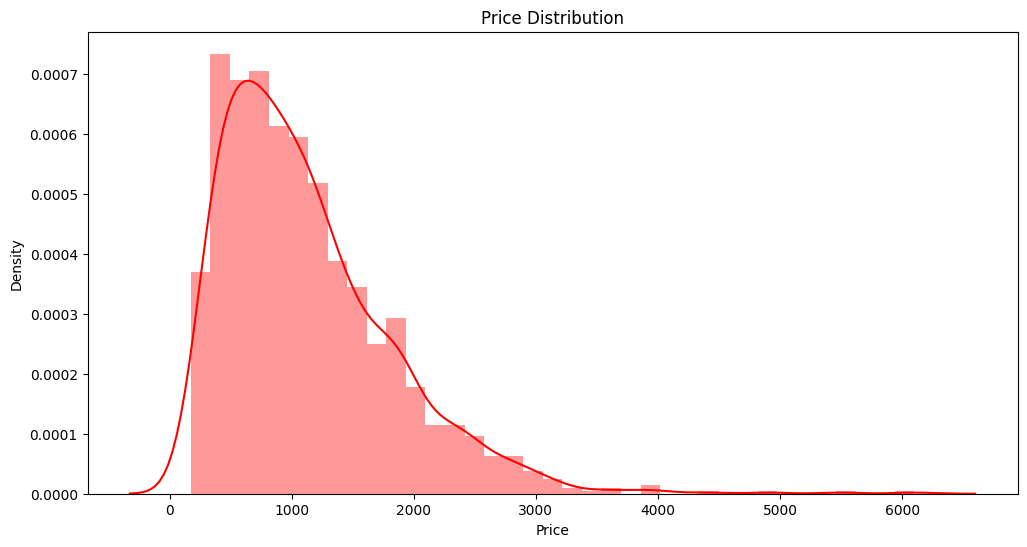

In [272]:

plt.figure(figsize = (12,6))
sns.distplot(dataset['Price_euros'], color = 'red')
plt.xlabel('Price')
plt.title('Price Distribution')
plt.show()

In [273]:
dataset['Price_euros'].skew()

np.float64(1.5208655681688525)

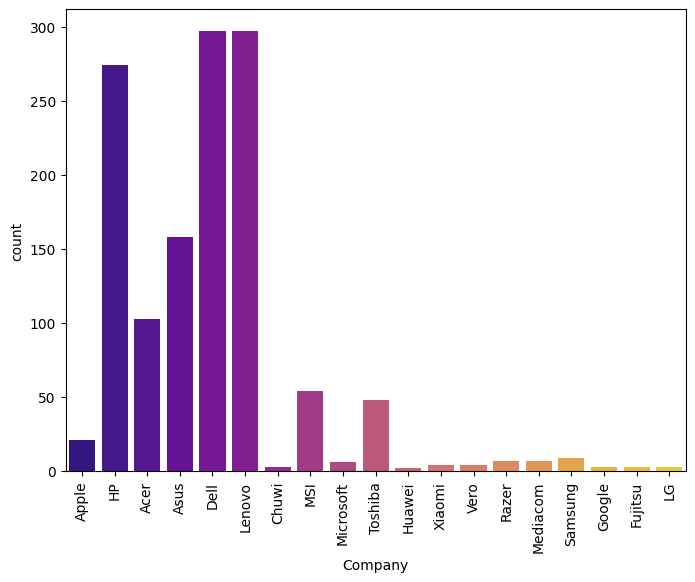

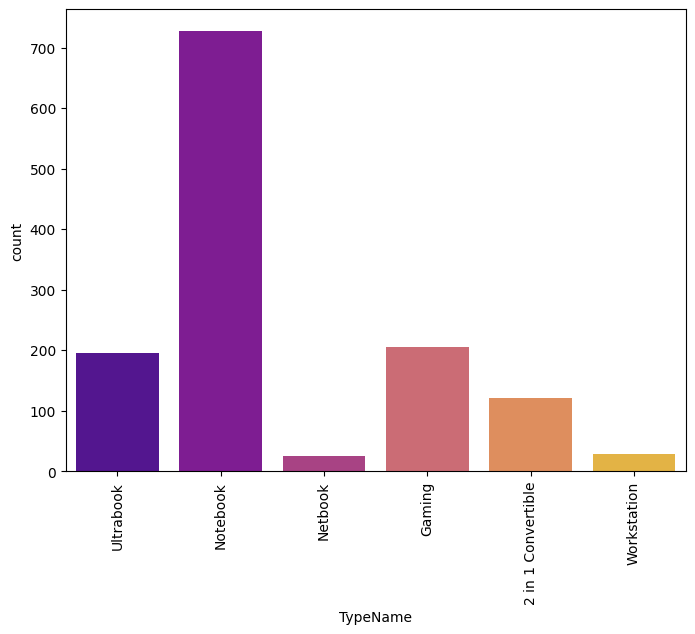

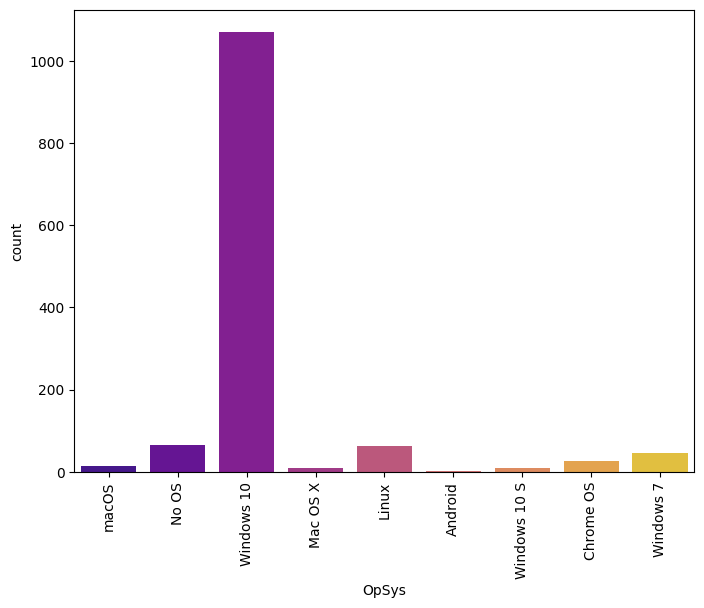

In [274]:
# Countplot for categorical feature having very less unique values

for feature in ['Company', 'TypeName', 'OpSys']:

    plt.figure(figsize = (8,6))
    sns.countplot(data = dataset, x = dataset[feature], palette = 'plasma')
    plt.xticks(rotation = 'vertical')

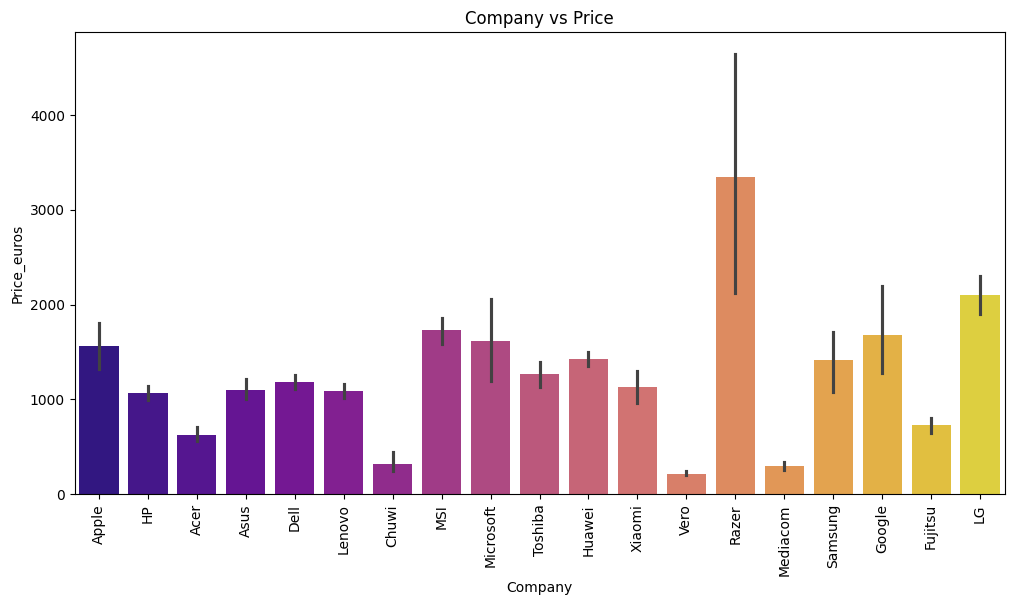

In [275]:
# Inflation check with 'Company'

plt.figure(figsize = (12,6))
sns.barplot(x = dataset.Company, y = dataset.Price_euros, palette = 'plasma')
plt.title('Company vs Price')
plt.xticks(rotation = 'vertical')
plt.show()

In [276]:
# Let's check unique vaues in TypeName column

dataset['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: Int64

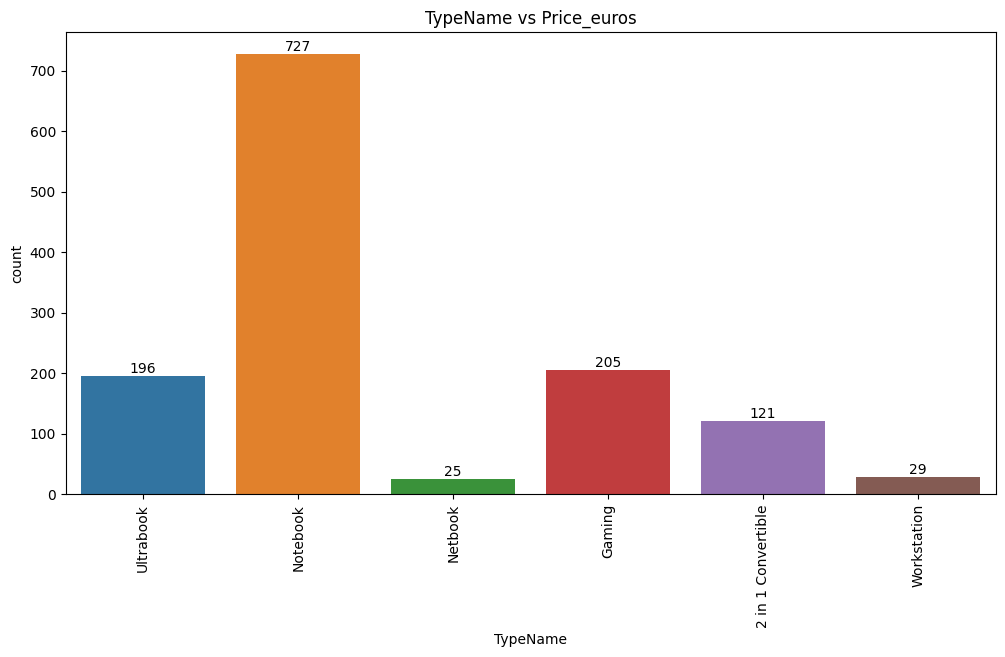

In [277]:
# Visualizing the TypeName

plt.figure(figsize = (12,6))
ax = sns.countplot(data = dataset, x = dataset['TypeName'], palette = 'tab10')

for label in ax.containers:
    ax.bar_label(label)
plt.title('TypeName vs Price_euros')
plt.xticks(rotation = 'vertical')
plt.show()

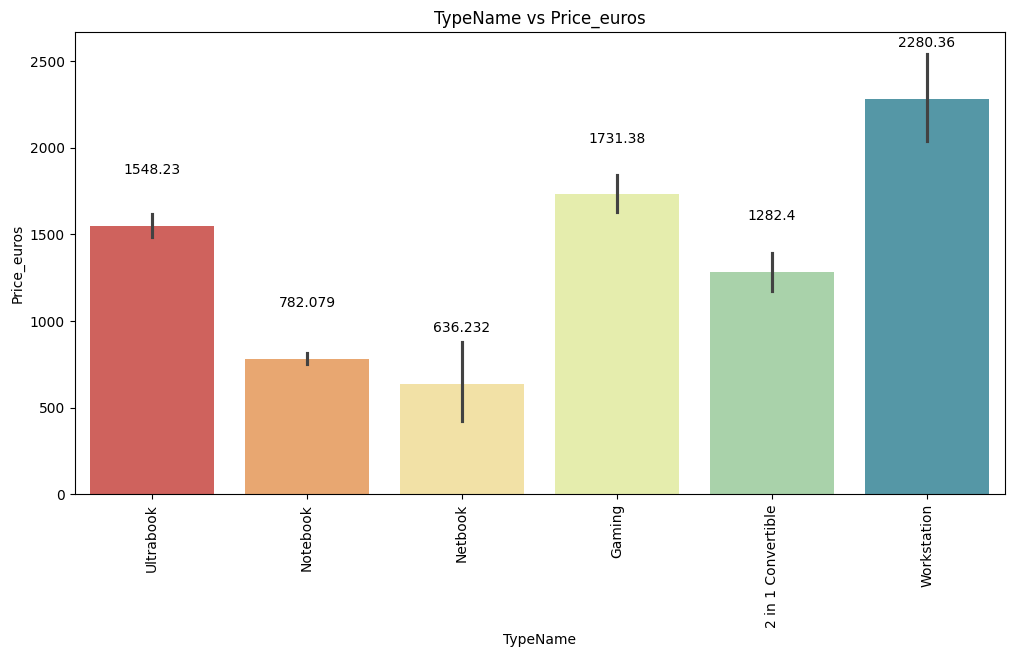

In [278]:
plt.figure(figsize = (12,6))
ax = sns.barplot(data = dataset, x = dataset['TypeName'], y = dataset['Price_euros'], palette = 'Spectral')

for label in ax.containers:
    ax.bar_label(label, padding=35)
plt.title('TypeName vs Price_euros')
plt.xticks(rotation = 'vertical')
plt.show()


In [279]:
# Check ScreenResolutions

dataset['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

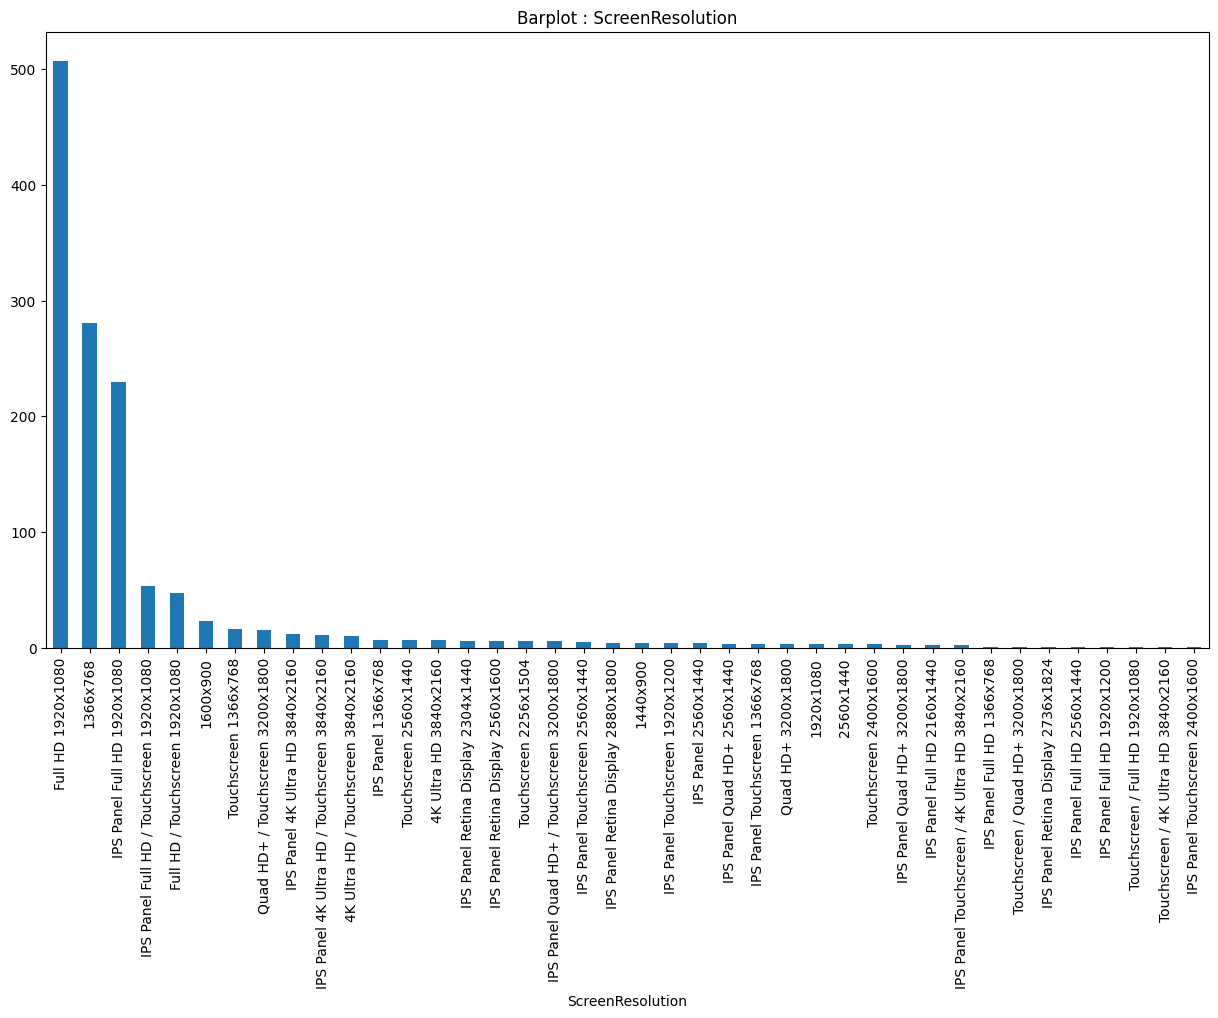

In [280]:
# Visualization
plt.figure(figsize = (15,8))
dataset['ScreenResolution'].value_counts().plot(kind='bar')
plt.title('Barplot : ScreenResolution')
plt.show()

In [281]:
# Create a feature 'TouchScreen'

dataset['TouchScreen'] = dataset['ScreenResolution'].apply(lambda element:1 if 'Touchscreen' in element else 0)

dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0


In [282]:
dataset['TouchScreen'].value_counts()

TouchScreen
0    1111
1     192
Name: count, dtype: int64

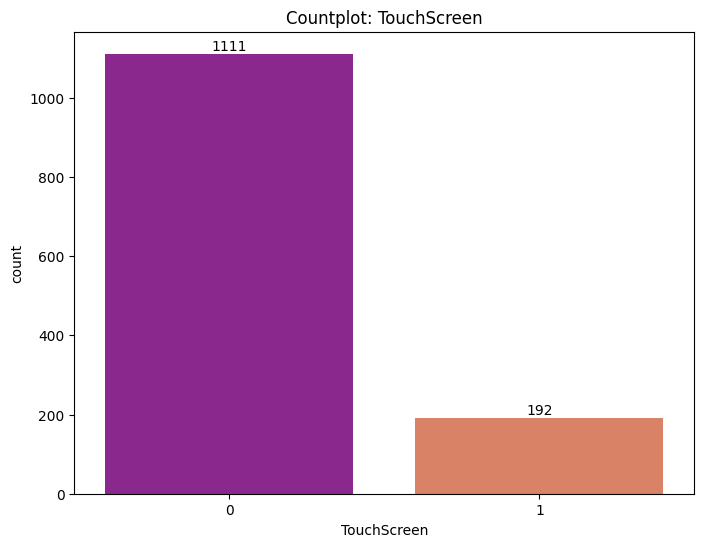

In [283]:
plt.figure(figsize = (8,6))
ax = sns.countplot(data = dataset, x = dataset['TouchScreen'], palette = 'plasma')
plt.title('Countplot: TouchScreen')

for label in ax.containers:
    ax.bar_label(label)

plt.show()

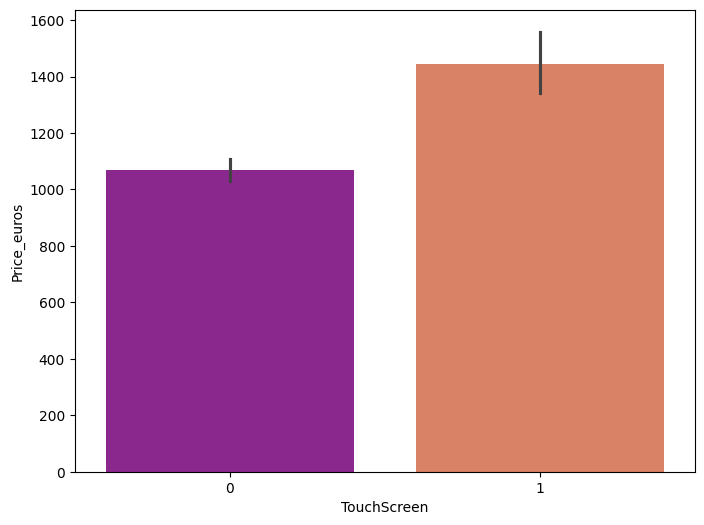

In [284]:
# Check inflation

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['TouchScreen'], y = dataset['Price_euros'],palette = 'plasma')
plt.show()

In [285]:
# Create a feature 'IPS'

dataset['IPS'] = dataset['ScreenResolution'].apply(lambda element:1 if 'IPS' in element else 0)

dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1


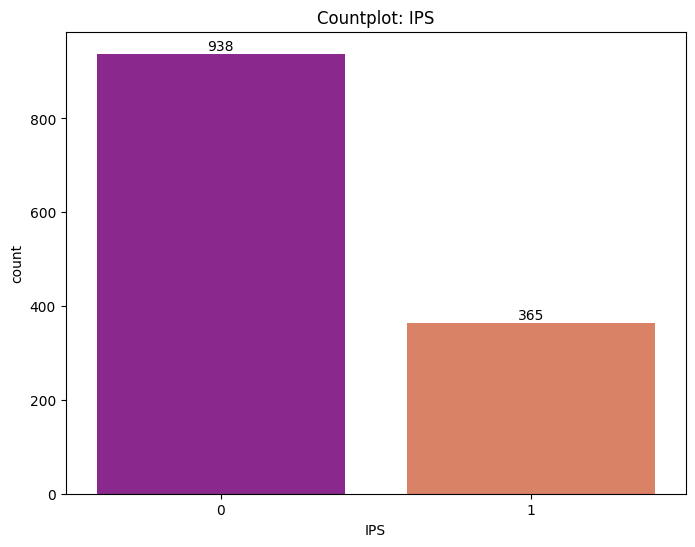

In [286]:
# Visualization

plt.figure(figsize = (8,6))
ax = sns.countplot(data = dataset, x = dataset['IPS'], palette = 'plasma')
plt.title('Countplot: IPS')

for label in ax.containers:
    ax.bar_label(label)
plt.show()

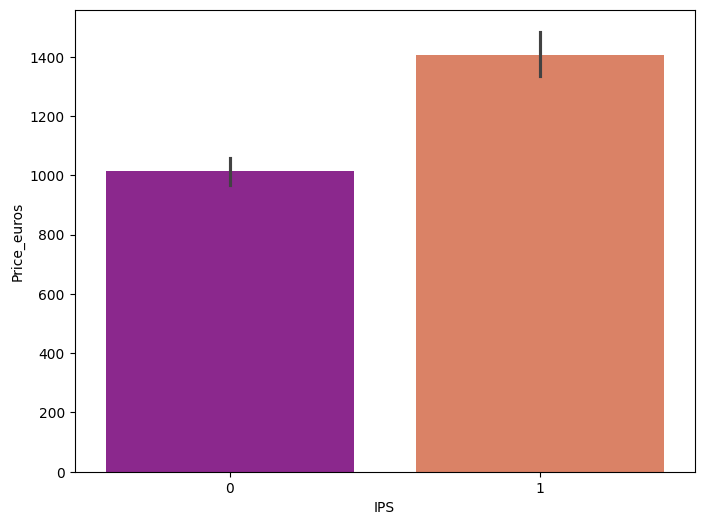

In [287]:
plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['IPS'], y = dataset['Price_euros'],palette = 'plasma')
plt.show()

In [288]:
# Extracting the X Resolution and Y Resolutions

dataset['ScreenResolution'].str.split('x',n=1,expand=True)

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [289]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   string 
 1   Product           1303 non-null   string 
 2   TypeName          1303 non-null   string 
 3   Inches            1303 non-null   Float64
 4   ScreenResolution  1303 non-null   string 
 5   Cpu               1303 non-null   string 
 6   Ram_GB            1303 non-null   Int32  
 7   Memory            1303 non-null   string 
 8   Gpu               1303 non-null   string 
 9   OpSys             1303 non-null   string 
 10  Weight_KG         1303 non-null   Float32
 11  Price_euros       1303 non-null   Float64
 12  TouchScreen       1303 non-null   int64  
 13  IPS               1303 non-null   int64  
dtypes: Float32(1), Float64(2), Int32(1), int64(2), string(8)
memory usage: 137.6 KB


In [290]:
dataset['X_res'] = dataset['ScreenResolution'].str.split('x',n=1,expand=True)[0]
dataset['Y_res'] = dataset['ScreenResolution'].str.split('x',n=1,expand=True)[1]



In [291]:
dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,X_res,Y_res
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,1440,900
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,Full HD 1920,1080
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,IPS Panel Retina Display 2880,1800
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,IPS Panel Retina Display 2560,1600


In [292]:
dataset['X_res'] = dataset['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x : x[0])

In [293]:
dataset.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,X_res,Y_res
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,2560,1600
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,1440,900
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,1920,1080
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,2880,1800
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,2560,1600


In [294]:
dataset = dataset.convert_dtypes()

In [295]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   string 
 1   Product           1303 non-null   string 
 2   TypeName          1303 non-null   string 
 3   Inches            1303 non-null   Float64
 4   ScreenResolution  1303 non-null   string 
 5   Cpu               1303 non-null   string 
 6   Ram_GB            1303 non-null   Int32  
 7   Memory            1303 non-null   string 
 8   Gpu               1303 non-null   string 
 9   OpSys             1303 non-null   string 
 10  Weight_KG         1303 non-null   Float32
 11  Price_euros       1303 non-null   Float64
 12  TouchScreen       1303 non-null   Int64  
 13  IPS               1303 non-null   Int64  
 14  X_res             1303 non-null   string 
 15  Y_res             1303 non-null   string 
dtypes: Float32(1), Float64(2), Int32(1), Int64

In [296]:
dataset['X_res'] = dataset['X_res'].astype('int')
dataset['Y_res'] = dataset['Y_res'].astype('int')

In [297]:
dataset['Product']

0                               MacBook Pro
1                               Macbook Air
2                                    250 G6
3                               MacBook Pro
4                               MacBook Pro
                       ...                 
1298                         Yoga 500-14ISK
1299                         Yoga 900-13ISK
1300                     IdeaPad 100S-14IBR
1301    15-AC110nv (i7-6500U/6GB/1TB/Radeon
1302    X553SA-XX031T (N3050/4GB/500GB/W10)
Name: Product, Length: 1303, dtype: string

In [298]:
dataset['Product'].value_counts()

Product
XPS 13                                   30
Inspiron 3567                            29
250 G6                                   21
Vostro 3568                              19
Legion Y520-15IKBN                       19
                                         ..
ThinkPad L460                             1
V510-15IKB (i5-7200U/8GB/256GB/FHD/No     1
Rog GL502VS                               1
Rog GL553VE-FY052T                        1
17-ak001nv (A6-9220/4GB/500GB/Radeon      1
Name: count, Length: 618, dtype: Int64

In [299]:
dataset.drop('Product', axis=1,inplace=True)

In [300]:
print("DataFrame Columns: ", dataset.columns)

DataFrame Columns:  Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram_GB',
       'Memory', 'Gpu', 'OpSys', 'Weight_KG', 'Price_euros', 'TouchScreen',
       'IPS', 'X_res', 'Y_res'],
      dtype='object')


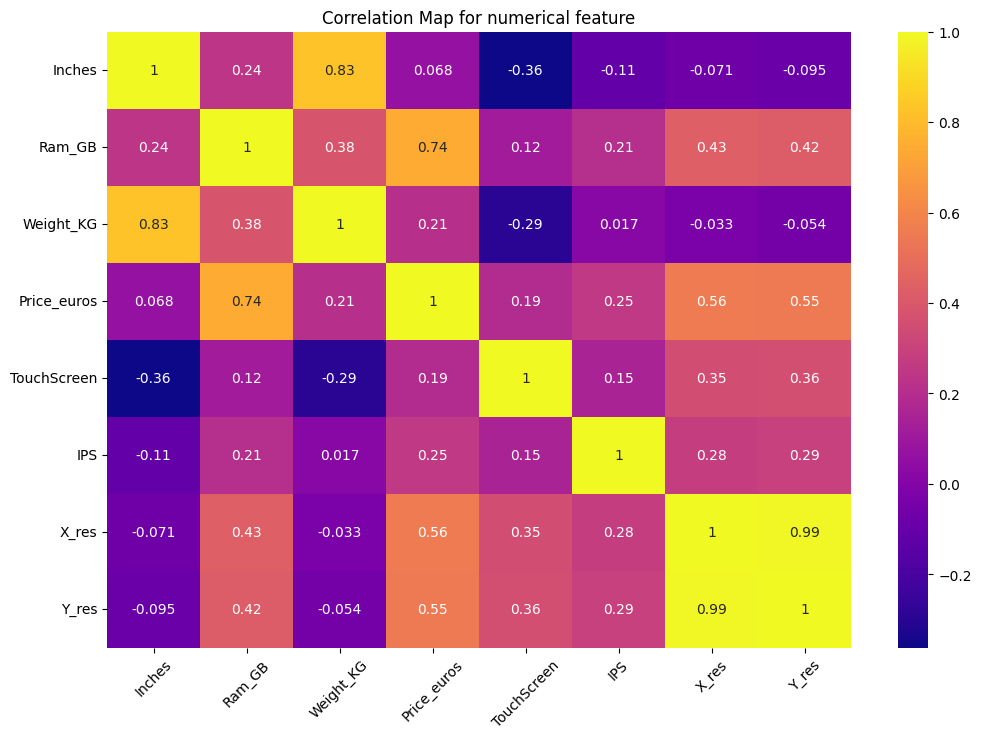

In [301]:
dataset_num = dataset[[feature for feature in dataset.columns if dataset[feature].dtypes != 'string']]

plt.figure(figsize = (12,8))
sns.heatmap(dataset_num .corr(), annot=True,cmap='plasma')
plt.title('Correlation Map for numerical feature')
plt.xticks(rotation=45)
plt.show()

In [302]:
dataset_num.corr()['Price_euros']

Inches         0.068197
Ram_GB         0.743007
Weight_KG      0.210370
Price_euros    1.000000
TouchScreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
Name: Price_euros, dtype: float64

In [303]:
# Create a new column called PPI

dataset['PPI'] = (np.round((dataset['X_res']**2 + dataset['Y_res']**2)**(1/2))/dataset['Inches']).astype('float')
dataset.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,2560,1600,226.992481
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,1440,900,127.669173
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,1920,1080,141.217949
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,2880,1800,220.519481
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,2560,1600,226.992481


In [304]:
# Check correlation between "Price and PPI"

dataset[['PPI','Price_euros']].corr()

,PPI,Price_euros
PPI,1.000000,0.473497
Price_euros,0.473497,1.000000


In [305]:
# Now I have a column created using X_res, Y_res, Inches.

# So I am going to drop these columns

# Now we can delete 'Inches', 'X_res' and 'Y_res'

dataset.drop(columns = ['Inches','ScreenResolution', 'X_res','Y_res'],inplace=True)
dataset.head()

,Company,TypeName,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481


In [306]:
# Lets check the Cpu

dataset['Cpu'].value_counts()


Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: Int64

In [307]:
# Create a column Cpu_name

dataset['Cpu_name'] = dataset['Cpu'].apply(lambda text:" ".join(text.split()[:3]))
dataset.head()

,Company,TypeName,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5


In [308]:
dataset['Cpu'][0].split()[:3]

['Intel', 'Core', 'i5']

In [309]:
dataset['Cpu_name'].value_counts()

Cpu_name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
AMD A9-Series 9410            3
Intel Pentium Dual            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD E-Series E2-9000e         2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD E-Series 7110             2
AMD A10-Series 9620P          2
AMD A10-Series 9600P          2
Intel Xeon E3-1505M           2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series 6110             1
AMD E-Series 9000e            1
AMD E-Series E2-6110          1
AMD FX 9830P                  1

In [310]:
# This is the function to organize the column Cpu_name

def processortype(text):

    if text == 'Intel Core i5' or text == 'Intel Core i7' or text == 'Intel Core i3':
        return text

    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'


dataset['Cpu_name'] = dataset['Cpu_name'].apply(lambda text:processortype(text))
dataset.head()

,Company,TypeName,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5


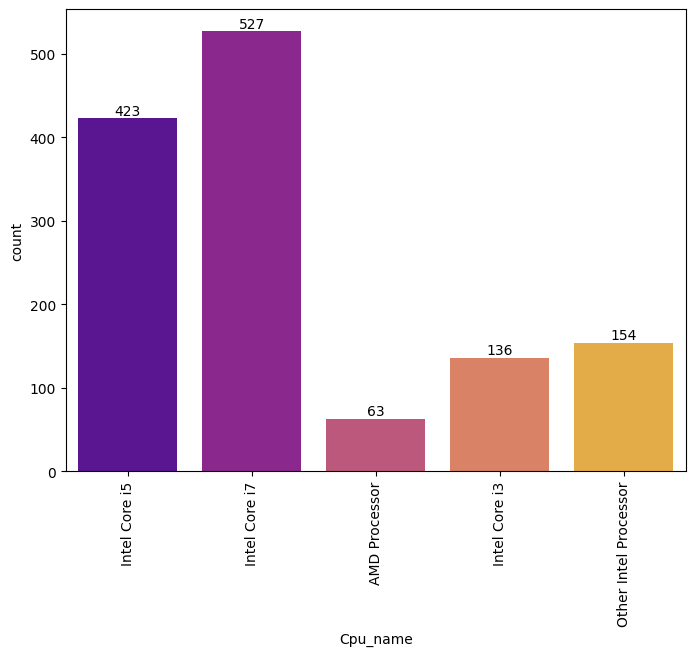

In [311]:
# Visualization of the changes made

plt.figure(figsize = (8,6))
ax = sns.countplot(data = dataset, x = dataset['Cpu_name'], palette='plasma')
plt.xticks(rotation = 'vertical')

for label in ax.containers:
    ax.bar_label(label)
plt.show()

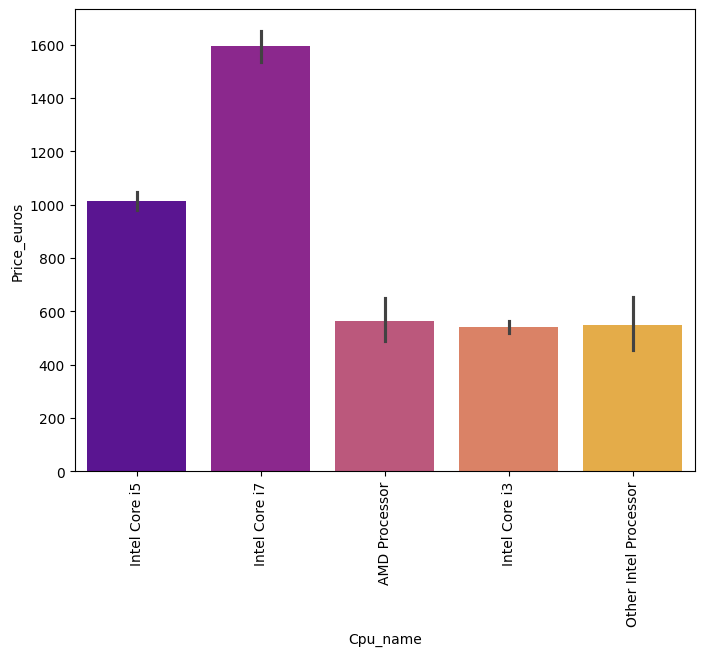

In [312]:
# Inflation with respect to cpu type

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['Cpu_name'], y = dataset['Price_euros'], palette='plasma')
plt.xticks(rotation = 'vertical')
plt.show()

In [313]:
# Now we will drop the Cpu column

dataset.drop(columns = ['Cpu'],inplace=True)

In [314]:
# check the dataset

dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5


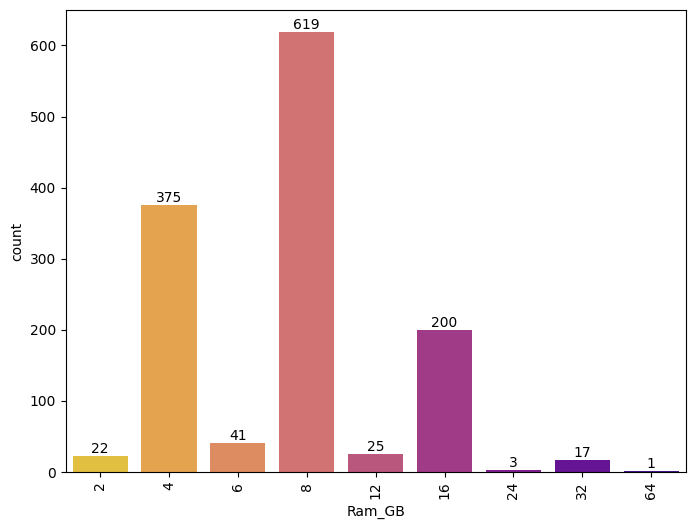

In [315]:
# Countplot of Ram

plt.figure(figsize = (8,6))
ax = sns.countplot(data = dataset, x = dataset['Ram_GB'], palette='plasma_r')
plt.xticks(rotation = 'vertical')

for label in ax.containers:
    ax.bar_label(label)
plt.show()

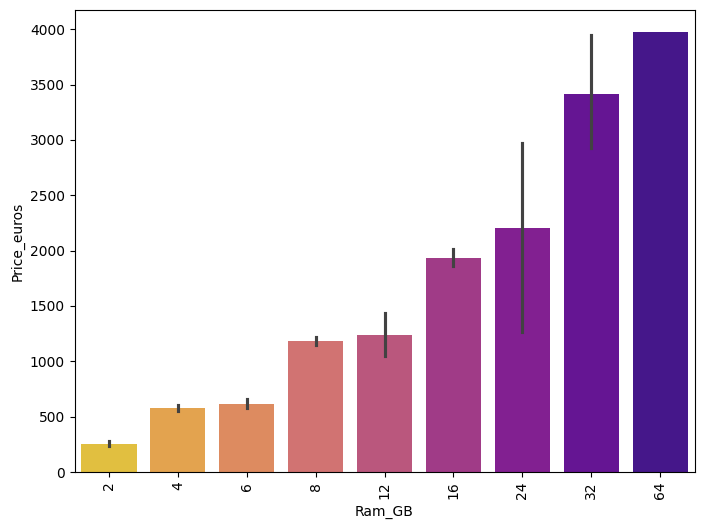

In [316]:
# Price variations w.r.t RAM

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['Ram_GB'], y = dataset['Price_euros'], palette='plasma_r')
plt.xticks(rotation = 'vertical')
plt.show()

In [317]:
# 'Memory' Column

dataset['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [318]:
# Preocess 'Memory' column

# The two units are available - GB and TB so needs to maintain the uniformity

# Remove the decimal for example 1.0 = 1
dataset['Memory'] = dataset['Memory'].astype(str).replace('\.0','',regex=True)

# Remove GB
dataset['Memory'] = dataset['Memory'].str.replace('GB','')

# Removve TB with 000
dataset['Memory'] = dataset['Memory'].str.replace('TB','000')

In [319]:
dataset['Memory'].value_counts()

Memory
256 SSD                         412
1000 HDD                        224
500 HDD                         132
512 SSD                         118
128 SSD +  1000 HDD              94
128 SSD                          76
256 SSD +  1000 HDD              73
32 Flash Storage                 38
2000 HDD                         16
64 Flash Storage                 15
512 SSD +  1000 HDD              14
1000 SSD                         14
256 SSD +  2000 HDD              10
1000 Hybrid                       9
256 Flash Storage                 8
16 Flash Storage                  7
32 SSD                            6
180 SSD                           5
128 Flash Storage                 4
512 SSD +  2000 HDD               3
16 SSD                            3
256 SSD +  256 SSD                2
512 Flash Storage                 2
1000 SSD +  1000 HDD              2
256 SSD +  500 HDD                2
128 SSD +  2000 HDD               2
512 SSD +  512 SSD                1
64 SSD               

In [320]:
# Split the Memory column with +

# split the text across '+'
newdf = dataset['Memory'].str.split('+',n=1,expand=True)
newdf

,0,1
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1298,128 SSD,None
1299,512 SSD,None
1300,64 Flash Storage,None
1301,1000 HDD,None


In [321]:
dataset['Memory_first'] = newdf[0]
dataset['Memory_first'] = dataset['Memory_first'].str.strip()
dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,Memory_first
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5,128 SSD
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5,128 Flash Storage
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5,256 SSD
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7,512 SSD
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5,256 SSD


In [322]:
# Creating a function that will take memory and and create different column of memory with suffix as the type

def applychanges(value):

    dataset['Memory_first-'+value] = dataset['Memory_first'].apply(lambda x:1 if value in x else 0)

valueList = ['SSD', 'HDD', 'Hybrid', 'Flash Storage']
for value in valueList:
    applychanges(value)

dataset.sample(10)

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,Memory_first,Memory_first-SSD,Memory_first-HDD,Memory_first-Hybrid,Memory_first-Flash Storage
741,Dell,Notebook,8,256 SSD,Intel HD Graphics 520,Windows 10,2.0,665.0,0,0,100.448718,Intel Core i3,256 SSD,1,0,0,0
830,Razer,Gaming,32,512 SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,5499.0,1,0,254.682081,Intel Core i7,512 SSD,1,0,0,0
699,HP,Notebook,4,500 HDD,AMD Radeon 530,Windows 10,2.1,689.0,0,1,141.217949,Intel Core i7,500 HDD,0,1,0,0
1022,HP,Notebook,8,256 SSD,Intel HD Graphics 620,Windows 10,1.11,1149.0,0,1,165.639098,Intel Core i5,256 SSD,1,0,0,0
331,Toshiba,Notebook,8,256 SSD,Intel HD Graphics 620,Windows 10,2.0,943.0,0,1,141.217949,Intel Core i5,256 SSD,1,0,0,0
952,Toshiba,Notebook,8,256 SSD,Intel HD Graphics 520,Windows 7,1.2,1460.0,0,0,165.639098,Intel Core i5,256 SSD,1,0,0,0
407,Dell,Ultrabook,8,512 SSD,Intel HD Graphics,Windows 10,1.36,1680.0,0,0,157.357143,Intel Core i7,512 SSD,1,0,0,0
1116,Lenovo,Gaming,16,256 SSD + 1000 Hybrid,Nvidia GeForce GTX 980M,Windows 10,4.6,2749.99,0,1,127.341040,Intel Core i7,256 SSD,1,0,0,0
484,Lenovo,Notebook,4,128 SSD,Intel HD Graphics 520,Windows 10,2.3,565.0,0,0,100.448718,Intel Core i3,128 SSD,1,0,0,0
718,Mediacom,Notebook,4,32 HDD,Intel HD Graphics 400,Windows 10,1.4,265.0,0,1,161.714286,Other Intel Processor,32 HDD,0,1,0,0


In [323]:
# Remove all the characters just keep the numbers

dataset['Memory_first'] = dataset['Memory_first'].str.replace(r'\D','',regex=True)
dataset['Memory_first'].value_counts()

Memory_first
256     508
1000    250
128     177
512     140
500     132
32       45
64       17
2000     16
16       10
180       5
240       1
8         1
508       1
Name: count, dtype: int64

In [324]:
# Applying same thing with memory second part as applied to memory first past 

dataset['Memory_second'] = newdf[1]
dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,Memory_first,Memory_first-SSD,Memory_first-HDD,Memory_first-Hybrid,Memory_first-Flash Storage,Memory_second
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5,128,1,0,0,0,None
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5,128,0,0,0,1,None
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5,256,1,0,0,0,None
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7,512,1,0,0,0,None
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5,256,1,0,0,0,None


In [325]:
# Check mising values

dataset['Memory_second'].isnull().sum()

np.int64(1095)

In [326]:
# Fill nan value with 0
dataset['Memory_second'] = dataset['Memory_second'].fillna("0")
dataset['Memory_second'].value_counts()

Memory_second
0                1095
  1000 HDD        185
  2000 HDD         15
  256 SSD           3
  500 HDD           2
  1000 Hybrid       2
  512 SSD           1
Name: count, dtype: int64

In [327]:
# Creating seperate column with memeory varients

def applychanges2(value):

    dataset['Memory_second-'+value] = dataset['Memory_second'].apply(lambda x:1 if value in x else 0)

valueList = ['SSD', 'HDD', 'Hybrid', 'Flash Storage']

for value in valueList:
    applychanges2(value)

dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,...,Memory_first,Memory_first-SSD,Memory_first-HDD,Memory_first-Hybrid,Memory_first-Flash Storage,Memory_second,Memory_second-SSD,Memory_second-HDD,Memory_second-Hybrid,Memory_second-Flash Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,...,128,1,0,0,0,0,0,0,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,...,128,0,0,0,1,0,0,0,0,0
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,...,256,1,0,0,0,0,0,0,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,...,512,1,0,0,0,0,0,0,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,...,256,1,0,0,0,0,0,0,0,0


In [328]:
# Remove all the characters just keep the numbers
dataset['Memory_second'] = dataset['Memory_second'].str.replace(r'\D','',regex=True)
dataset['Memory_second'].value_counts()

Memory_second
0       1095
1000     187
2000      15
256        3
500        2
512        1
Name: count, dtype: int64

In [329]:
# Check dataframe information

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      1303 non-null   string 
 1   TypeName                     1303 non-null   string 
 2   Ram_GB                       1303 non-null   Int32  
 3   Memory                       1303 non-null   object 
 4   Gpu                          1303 non-null   string 
 5   OpSys                        1303 non-null   string 
 6   Weight_KG                    1303 non-null   Float32
 7   Price_euros                  1303 non-null   Float64
 8   TouchScreen                  1303 non-null   Int64  
 9   IPS                          1303 non-null   Int64  
 10  PPI                          1303 non-null   float64
 11  Cpu_name                     1303 non-null   object 
 12  Memory_first                 1303 non-null   object 
 13  Memory_first-SSD  

In [330]:
# Converting the data type of columns Memory_first and Memory_second

dataset['Memory_first'] = dataset['Memory_first'].astype('int')
dataset['Memory_second'] = dataset['Memory_second'].astype('int')

In [331]:
# Check dataframe information

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      1303 non-null   string 
 1   TypeName                     1303 non-null   string 
 2   Ram_GB                       1303 non-null   Int32  
 3   Memory                       1303 non-null   object 
 4   Gpu                          1303 non-null   string 
 5   OpSys                        1303 non-null   string 
 6   Weight_KG                    1303 non-null   Float32
 7   Price_euros                  1303 non-null   Float64
 8   TouchScreen                  1303 non-null   Int64  
 9   IPS                          1303 non-null   Int64  
 10  PPI                          1303 non-null   float64
 11  Cpu_name                     1303 non-null   object 
 12  Memory_first                 1303 non-null   int64  
 13  Memory_first-SSD  

In [332]:
# Multiplying the column and storing the result in sunsequent column

dataset['HDD'] = (dataset['Memory_first']*dataset['Memory_first-HDD']+dataset['Memory_second']*dataset['Memory_second-HDD'])
dataset['SSD'] = (dataset['Memory_first']*dataset['Memory_first-SSD']+dataset['Memory_second']*dataset['Memory_second-SSD'])
dataset['Hybrid'] = (dataset['Memory_first']*dataset['Memory_first-Hybrid']+dataset['Memory_second']*dataset['Memory_second-Hybrid'])
dataset['Flash Storage'] = (dataset['Memory_first']*dataset['Memory_first-Flash Storage']+dataset['Memory_second']*dataset['Memory_second-Flash Storage'])

In [333]:
# Check top 5 samples
dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,...,Memory_first-Flash Storage,Memory_second,Memory_second-SSD,Memory_second-HDD,Memory_second-Hybrid,Memory_second-Flash Storage,HDD,SSD,Hybrid,Flash Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,...,0,0,0,0,0,0,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,...,1,0,0,0,0,0,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,...,0,0,0,0,0,0,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,...,0,0,0,0,0,0,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,...,0,0,0,0,0,0,0,256,0,0


In [334]:
dataset.iloc[0]

Company                                               Apple
TypeName                                          Ultrabook
Ram_GB                                                    8
Memory                                              128 SSD
Gpu                            Intel Iris Plus Graphics 640
OpSys                                                 macOS
Weight_KG                                              1.37
Price_euros                                         1339.69
TouchScreen                                               0
IPS                                                       1
PPI                                              226.992481
Cpu_name                                      Intel Core i5
Memory_first                                            128
Memory_first-SSD                                          1
Memory_first-HDD                                          0
Memory_first-Hybrid                                       0
Memory_first-Flash Storage              

In [335]:
# check the columns

dataset.columns

Index(['Company', 'TypeName', 'Ram_GB', 'Memory', 'Gpu', 'OpSys', 'Weight_KG',
       'Price_euros', 'TouchScreen', 'IPS', 'PPI', 'Cpu_name', 'Memory_first',
       'Memory_first-SSD', 'Memory_first-HDD', 'Memory_first-Hybrid',
       'Memory_first-Flash Storage', 'Memory_second', 'Memory_second-SSD',
       'Memory_second-HDD', 'Memory_second-Hybrid',
       'Memory_second-Flash Storage', 'HDD', 'SSD', 'Hybrid', 'Flash Storage'],
      dtype='object')

In [336]:
# As we created the seperate column for memory, lets delet few columns

dataset.drop(columns = ['Memory_first','Memory_second','Memory_first-SSD', 'Memory_first-HDD', 'Memory_first-Hybrid',
                   'Memory_first-Flash Storage','Memory_second-SSD','Memory_second-HDD', 'Memory_second-Hybrid',
                   'Memory_second-Flash Storage'],inplace = True)

In [337]:
dataset.head()

,Company,TypeName,Ram_GB,Memory,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,HDD,SSD,Hybrid,Flash Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5,0,256,0,0


In [338]:
dataset.drop(columns = ['Memory'], inplace = True)

dataset.head()

,Company,TypeName,Ram_GB,Gpu,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,HDD,SSD,Hybrid,Flash Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.992481,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,127.669173,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,575.0,0,0,141.217949,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,220.519481,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,1803.6,0,1,226.992481,Intel Core i5,0,256,0,0


In [339]:
# check dataset shape

dataset.shape

(1303, 15)

In [340]:
# check the correlation between memeories and price

dataset[['HDD','SSD','Hybrid','Flash Storage','Price_euros']].corr()

,HDD,SSD,Hybrid,Flash Storage,Price_euros
HDD,1.000000,-0.399896,-0.076596,-0.117658,-0.096441
SSD,-0.399896,1.000000,-0.059750,-0.147991,0.670799
Hybrid,-0.076596,-0.059750,1.000000,-0.014368,0.007989
Flash Storage,-0.117658,-0.147991,-0.014368,1.000000,-0.040511
Price_euros,-0.096441,0.670799,0.007989,-0.040511,1.000000


In [341]:
# so drop the Hybrid and Flash Storagre column

dataset.drop(columns = ['Hybrid','Flash Storage'], inplace = True)

In [342]:
# Analysing 'Gpu'

dataset['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: Int64

In [343]:
# Create a column for GPU Brand

dataset['Gpu_brand'] = dataset['Gpu'].str.split(' ').apply(lambda x:x[0])

In [344]:
dataset['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

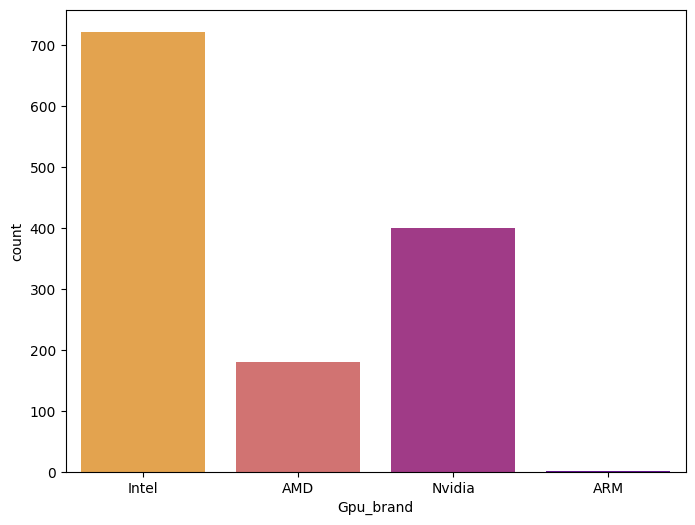

In [345]:
plt.figure(figsize = (8,6))
sns.countplot(data = dataset, x = dataset['Gpu_brand'], palette = 'plasma_r')
plt.show()

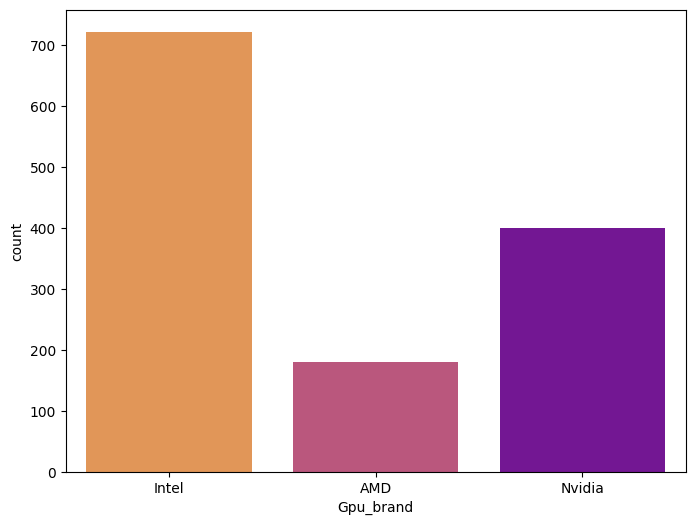

In [346]:
# Remove all laptop have gpu brand 'ARM'

dataset = dataset[dataset['Gpu_brand'] != 'ARM']

plt.figure(figsize = (8,6))
sns.countplot(data = dataset, x = dataset['Gpu_brand'], palette = 'plasma_r')
plt.show()


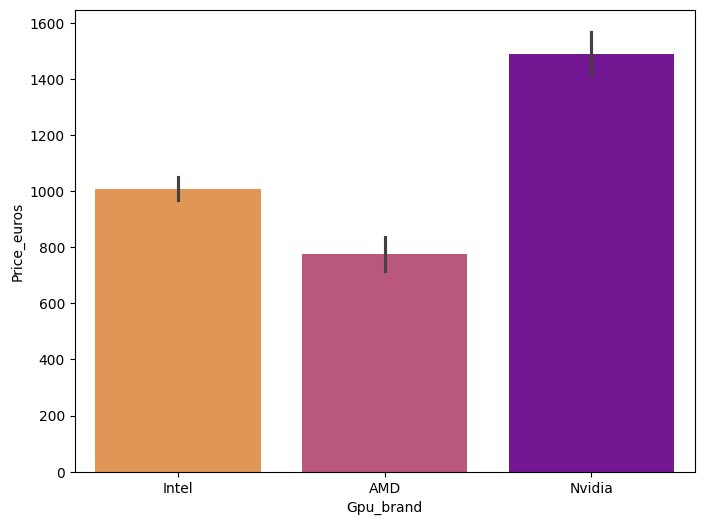

In [347]:
# Inflation with respect to GPU Brand

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['Gpu_brand'], y = dataset['Price_euros'], palette = 'plasma_r')
plt.show()

In [348]:
dataset.drop(columns = ['Gpu'], inplace = True)

In [349]:
# Operating System Analysis

dataset['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: Int64

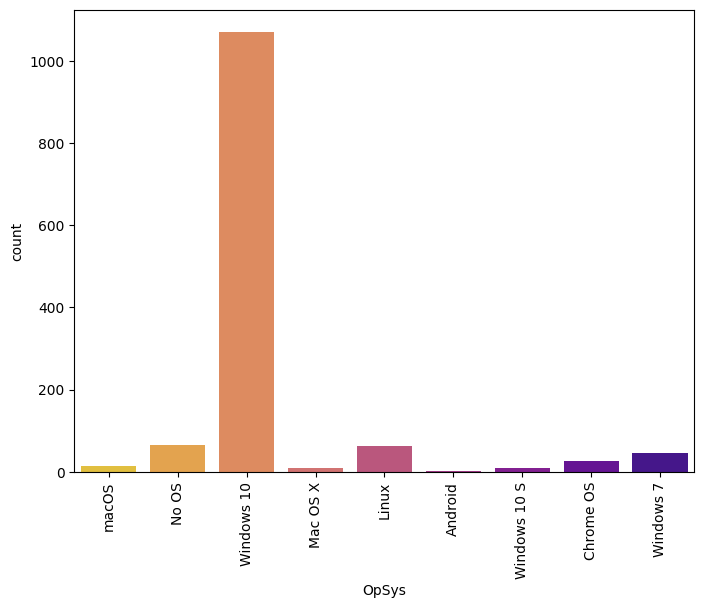

In [350]:
# Visualization with Countplot

plt.figure(figsize = (8,6))
sns.countplot(data = dataset, x = dataset['OpSys'], palette = 'plasma_r')
plt.xticks(rotation = 'vertical')
plt.show()

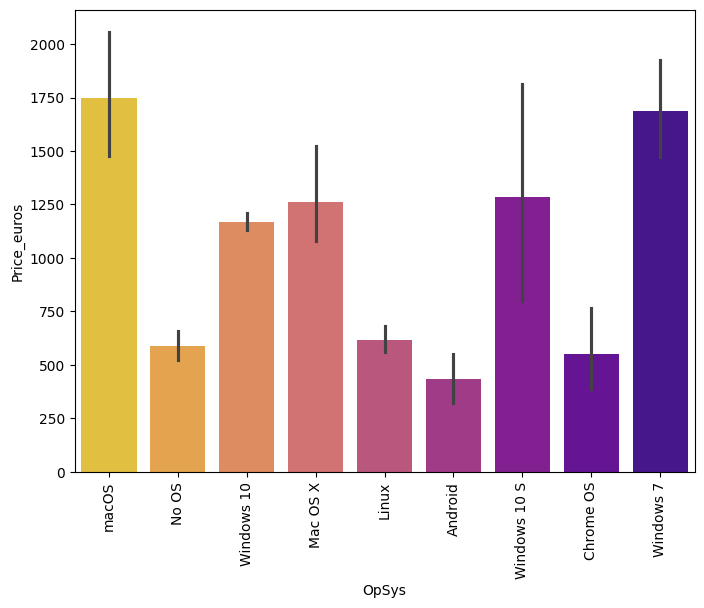

In [351]:
# Variation in price

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['OpSys'], y = dataset['Price_euros'], palette = 'plasma_r')
plt.xticks(rotation = 'vertical')
plt.show()


In [352]:
# Clubing Windows all variations

def clubWindows(text):

    if text == 'Windows 10' or text == 'Windows 10 S' or text == 'Windows 7':
        return 'Windows'
    elif text == 'Mac OS X' or text == 'macOS':
        return 'MaC'
    else:
        return 'Others'

dataset['OpSys'] = dataset['OpSys'].apply(lambda x:clubWindows(x))

dataset['OpSys'].value_counts()

OpSys
Windows    1125
Others      156
MaC          21
Name: count, dtype: int64

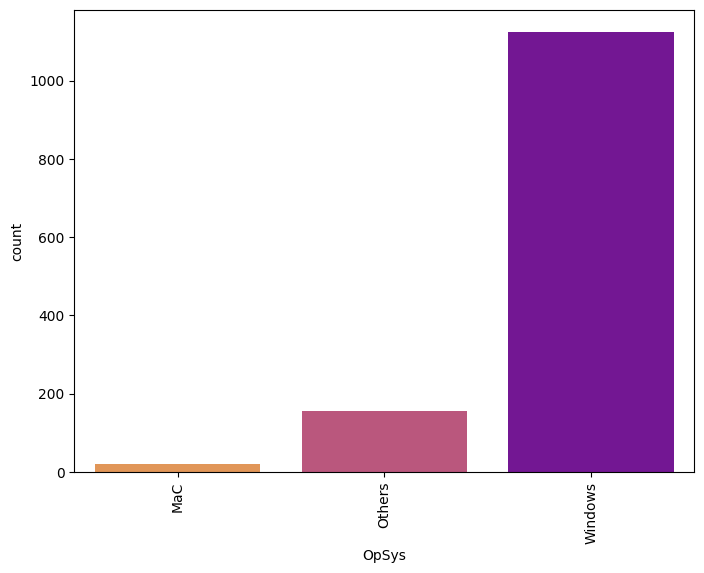

In [353]:
# Visualization

plt.figure(figsize = (8,6))
sns.countplot(data = dataset, x = dataset['OpSys'], palette = 'plasma_r')
plt.xticks(rotation = 'vertical')
plt.show()

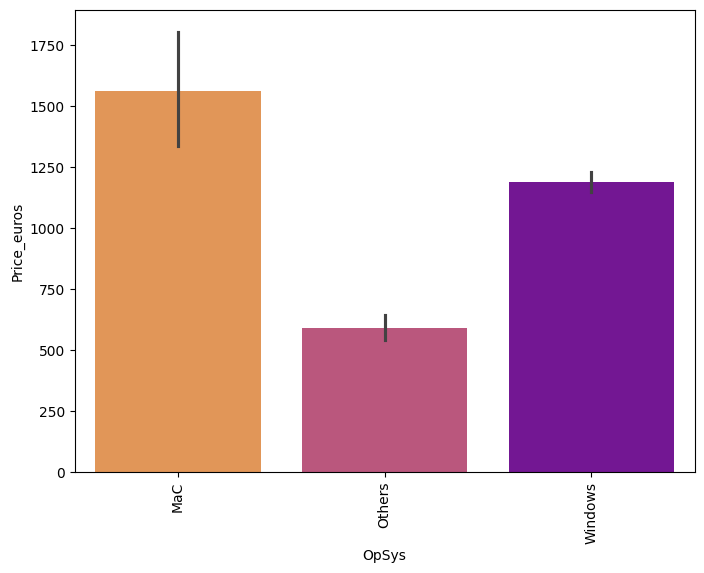

In [354]:
# Variation in price

plt.figure(figsize = (8,6))
sns.barplot(data = dataset, x = dataset['OpSys'], y = dataset['Price_euros'], palette = 'plasma_r')
plt.xticks(rotation = 'vertical')
plt.show()

In [355]:
# Weight Analysis

dataset['Weight_KG']

0       1.37
1       1.34
2       1.86
3       1.83
4       1.37
        ... 
1298     1.8
1299     1.3
1300     1.5
1301    2.19
1302     2.2
Name: Weight_KG, Length: 1302, dtype: Float32

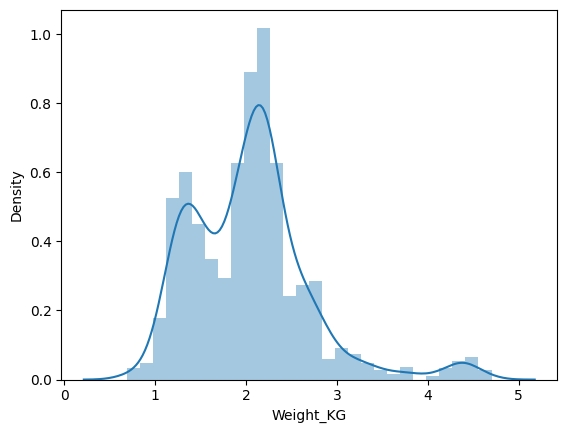

In [356]:
# Distribution plot

sns.distplot(dataset['Weight_KG'])
plt.show()

<Axes: xlabel='Weight_KG', ylabel='Price_euros'>

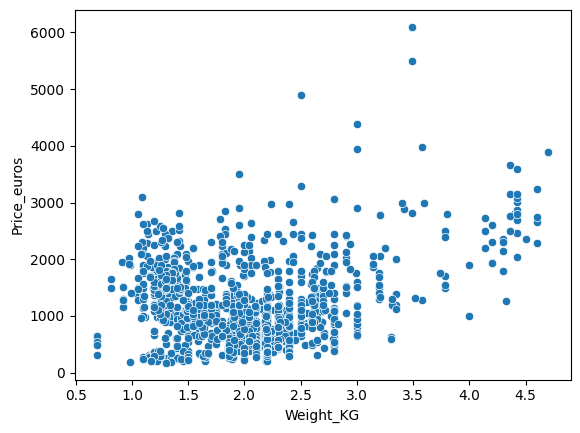

In [357]:
# Price variations w.r.t Weight

sns.scatterplot(data = dataset, x = dataset['Weight_KG'], y = dataset['Price_euros'])

<Axes: xlabel='Price_euros', ylabel='Density'>

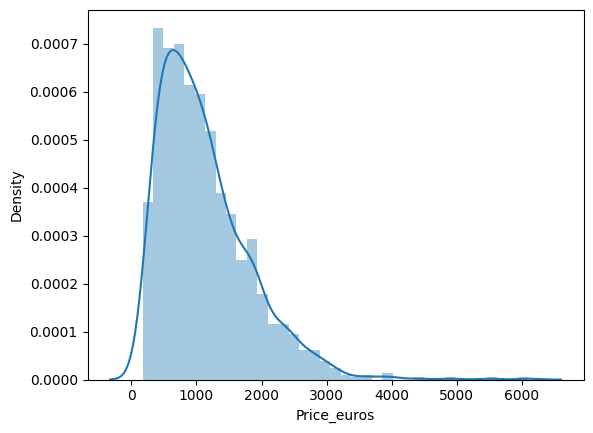

In [358]:
# Price analysis

sns.distplot(dataset['Price_euros'])

<Axes: xlabel='Price_euros', ylabel='Density'>

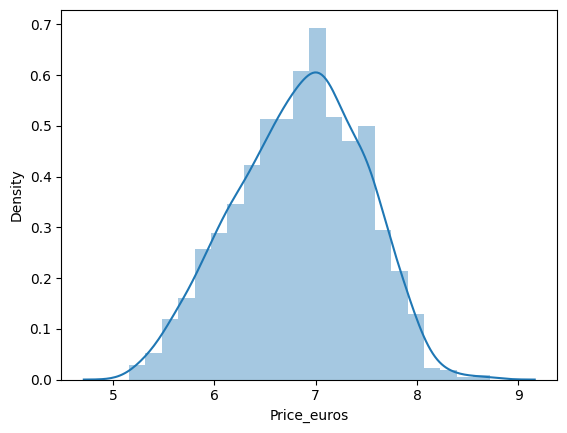

In [359]:
# apply log to normaize price

sns.distplot(np.log(dataset['Price_euros']))

In [360]:
dataset.head()

,Company,TypeName,Ram_GB,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,MaC,1.37,1339.69,0,1,226.992481,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,MaC,1.34,898.94,0,0,127.669173,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Others,1.86,575.0,0,0,141.217949,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,MaC,1.83,2537.45,0,1,220.519481,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,MaC,1.37,1803.6,0,1,226.992481,Intel Core i5,0,256,Intel


In [361]:
df_clean = dataset.copy()
df_clean

,Company,TypeName,Ram_GB,OpSys,Weight_KG,Price_euros,TouchScreen,IPS,PPI,Cpu_name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,MaC,1.37,1339.69,0,1,226.992481,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,MaC,1.34,898.94,0,0,127.669173,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Others,1.86,575.0,0,0,141.217949,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,MaC,1.83,2537.45,0,1,220.519481,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,MaC,1.37,1803.6,0,1,226.992481,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Windows,1.8,638.0,1,1,157.357143,Intel Core i7,0,128,Intel
1299,Lenovo,2 in 1 Convertible,16,Windows,1.3,1499.0,1,1,276.090226,Intel Core i7,0,512,Intel
1300,Lenovo,Notebook,2,Windows,1.5,229.0,0,0,111.928571,Other Intel Processor,0,0,Intel
1301,HP,Notebook,6,Windows,2.19,764.0,0,0,100.448718,Intel Core i7,1000,0,AMD


In [362]:
# Basic info

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1302 non-null   string 
 1   TypeName     1302 non-null   string 
 2   Ram_GB       1302 non-null   Int32  
 3   OpSys        1302 non-null   object 
 4   Weight_KG    1302 non-null   Float32
 5   Price_euros  1302 non-null   Float64
 6   TouchScreen  1302 non-null   Int64  
 7   IPS          1302 non-null   Int64  
 8   PPI          1302 non-null   float64
 9   Cpu_name     1302 non-null   object 
 10  HDD          1302 non-null   int64  
 11  SSD          1302 non-null   int64  
 12  Gpu_brand    1302 non-null   object 
dtypes: Float32(1), Float64(1), Int32(1), Int64(2), float64(1), int64(2), object(3), string(2)
memory usage: 138.6+ KB


In [363]:
dataset = dataset.convert_dtypes()

In [364]:
# Creating two lists to hold the numeric and categorical dataset

numF = [feature for feature in dataset.columns if dataset[feature].dtypes != 'string']
catF = [feature for feature in dataset.columns if dataset[feature].dtypes == 'string']

In [365]:
numF

['Ram_GB',
 'Weight_KG',
 'Price_euros',
 'TouchScreen',
 'IPS',
 'PPI',
 'HDD',
 'SSD']

In [366]:
numF

['Ram_GB',
 'Weight_KG',
 'Price_euros',
 'TouchScreen',
 'IPS',
 'PPI',
 'HDD',
 'SSD']

In [367]:
# create a dataframe with numeric feature

dfnum = df_clean[numF]

In [368]:
dfnum

,Ram_GB,Weight_KG,Price_euros,TouchScreen,IPS,PPI,HDD,SSD
0,8,1.37,1339.69,0,1,226.992481,0,128
1,8,1.34,898.94,0,0,127.669173,0,0
2,8,1.86,575.0,0,0,141.217949,0,256
3,16,1.83,2537.45,0,1,220.519481,0,512
4,8,1.37,1803.6,0,1,226.992481,0,256
...,...,...,...,...,...,...,...,...
1298,4,1.8,638.0,1,1,157.357143,0,128
1299,16,1.3,1499.0,1,1,276.090226,0,512
1300,2,1.5,229.0,0,0,111.928571,0,0
1301,6,2.19,764.0,0,0,100.448718,1000,0


In [369]:
# checking correlation

dfnum.corr()

,Ram_GB,Weight_KG,Price_euros,TouchScreen,IPS,PPI,HDD,SSD
Ram_GB,1.000000,0.383362,0.742905,0.118875,0.207949,0.305712,0.095808,0.603379
Weight_KG,0.383362,1.000000,0.209867,-0.293004,0.018643,-0.321842,0.514147,-0.063818
Price_euros,0.742905,0.209867,1.000000,0.192917,0.253320,0.475377,-0.096891,0.670660
TouchScreen,0.118875,-0.293004,0.192917,1.000000,0.148026,0.458553,-0.208766,0.257577
IPS,0.207949,0.018643,0.253320,0.148026,1.000000,0.299145,-0.093588,0.225311
PPI,0.305712,-0.321842,0.475377,0.458553,0.299145,1.000000,-0.294678,0.509451
HDD,0.095808,0.514147,-0.096891,-0.208766,-0.093588,-0.294678,1.000000,-0.400750
SSD,0.603379,-0.063818,0.670660,0.257577,0.225311,0.509451,-0.400750,1.000000


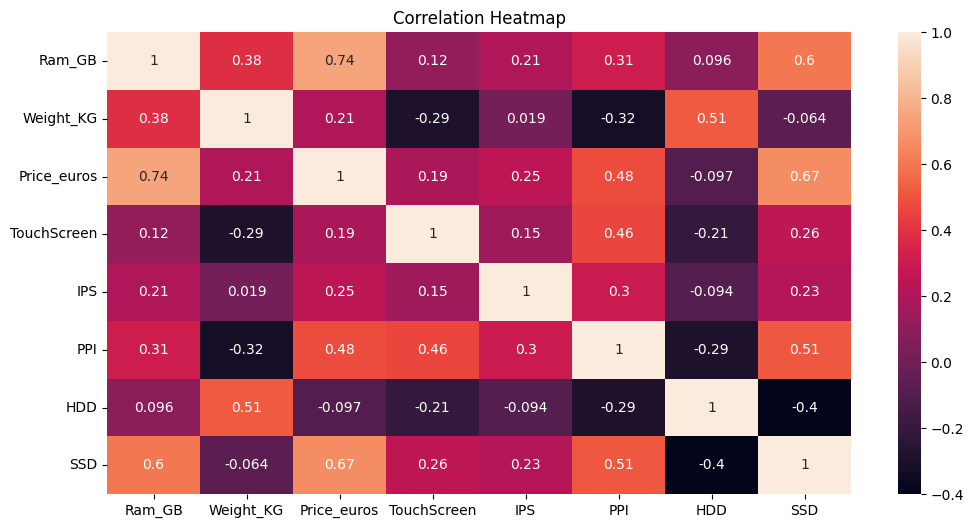

In [370]:
plt.figure(figsize = (12,6))
sns.heatmap(dfnum.corr(), annot = True)
plt.title('Correlation Heatmap')
plt.show()

In [371]:
dataset.columns


Index(['Company', 'TypeName', 'Ram_GB', 'OpSys', 'Weight_KG', 'Price_euros',
       'TouchScreen', 'IPS', 'PPI', 'Cpu_name', 'HDD', 'SSD', 'Gpu_brand'],
      dtype='object')

In [373]:
# Getting my X and y

X = df_clean.drop(['Price_euros'],axis=1)

y = np.log(df_clean['Price_euros'])

In [374]:
X


,Company,TypeName,Ram_GB,OpSys,Weight_KG,TouchScreen,IPS,PPI,Cpu_name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,MaC,1.37,0,1,226.992481,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,MaC,1.34,0,0,127.669173,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Others,1.86,0,0,141.217949,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,MaC,1.83,0,1,220.519481,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,MaC,1.37,0,1,226.992481,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Windows,1.8,1,1,157.357143,Intel Core i7,0,128,Intel
1299,Lenovo,2 in 1 Convertible,16,Windows,1.3,1,1,276.090226,Intel Core i7,0,512,Intel
1300,Lenovo,Notebook,2,Windows,1.5,0,0,111.928571,Other Intel Processor,0,0,Intel
1301,HP,Notebook,6,Windows,2.19,0,0,100.448718,Intel Core i7,1000,0,AMD


In [375]:
y

0       7.200194
1       6.801216
2        6.35437
3       7.838915
4        7.49754
          ...   
1298    6.458338
1299    7.312553
1300    5.433722
1301    6.638568
1302    5.910797
Name: Price_euros, Length: 1302, dtype: Float64

In [376]:
# Saving dataframe as csv

X.to_csv('traintest.csv', index=False)

MODEL DEVELOPMENT

In [377]:
# Importing library for model building

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [378]:
# Spliting dataset into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1106, 12), (196, 12), (1106,), (196,))

In [379]:
mapper = {i:value for i,value in enumerate(X_train.columns)}

mapper

{0: 'Company',
 1: 'TypeName',
 2: 'Ram_GB',
 3: 'OpSys',
 4: 'Weight_KG',
 5: 'TouchScreen',
 6: 'IPS',
 7: 'PPI',
 8: 'Cpu_name',
 9: 'HDD',
 10: 'SSD',
 11: 'Gpu_brand'}

In [380]:
# columnTransformer will use to apply different trasformation to different columns

step1 = ColumnTransformer(transformers = [('col_tnf', OneHotEncoder(sparse_output = False, drop = 'first'),[0,1,3,8,11])],remainder = 'passthrough')

In [381]:
step2 = LinearRegression()

In [382]:
regression_pipeline = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

In [383]:
X_train.columns

Index(['Company', 'TypeName', 'Ram_GB', 'OpSys', 'Weight_KG', 'TouchScreen',
       'IPS', 'PPI', 'Cpu_name', 'HDD', 'SSD', 'Gpu_brand'],
      dtype='object')

In [384]:
regression_pipeline.fit(X_train,y_train)

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('col_tnf', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [385]:
coefficients = regression_pipeline .named_steps['step2'].coef_
intercept = regression_pipeline .named_steps['step2'].intercept_

print('coefficients\n')
print(coefficients)
print('\n')
print('intercept\n')
print(intercept)

coefficients

[ 3.07044239e-01  1.08391539e-01 -3.25734233e-01  1.57800887e-01
 -2.05597991e-03  4.77848564e-01  1.88664443e-01  5.08057577e-02
  4.58680518e-01  1.05908468e-01  2.13758527e-01 -2.89265960e-01
  4.14394493e-01  2.60026925e-01  3.28367085e-01  3.11663372e-01
 -5.09370788e-01  3.65534878e-01 -1.40944948e-02 -2.04166654e-01
 -2.23107418e-01  2.69571022e-02  5.00558037e-01 -2.68981046e-01
 -3.80631938e-02  7.89146951e-02  3.89749471e-01  4.50304052e-01
 -1.75203681e-01  1.04728619e-01  9.46067892e-02  2.45454639e-02
  8.45816029e-02 -1.06161703e-01  3.94970916e-02  2.37946025e-03
  8.26267261e-06  6.23784408e-04]


intercept

5.656016528938877


In [386]:
y_pred_LR = regression_pipeline.predict(X_test)
y_pred_LR

array([6.73995697, 5.71233467, 6.08215907, 6.3886321 , 6.95520093,
       7.42932259, 6.28334069, 6.43364678, 7.16910102, 5.61653262,
       6.95116007, 7.05635187, 7.76322801, 6.91325292, 8.00184611,
       6.8600843 , 6.82209117, 5.62670867, 7.41147649, 7.51143965,
       7.69573076, 7.13293284, 6.84386414, 7.30967163, 6.52985406,
       7.79698669, 7.07352198, 6.15219287, 6.91631631, 6.64733872,
       7.11536536, 6.04723074, 6.61236793, 7.08096101, 7.13458068,
       6.81189073, 6.95879587, 6.98100906, 7.23797964, 7.45458039,
       7.71332488, 7.29154081, 5.77710651, 6.0242735 , 6.22395211,
       6.03488453, 7.03124121, 7.9488529 , 7.55048895, 6.8652697 ,
       7.54592851, 7.50789952, 5.77523693, 5.55097061, 6.76299228,
       6.80795999, 6.09242144, 7.08896744, 6.23279742, 6.49844655,
       7.02380118, 7.12612253, 5.90511632, 6.49970388, 6.80849634,
       6.57663716, 6.05659937, 7.48469014, 6.77039895, 5.94738386,
       6.99893067, 6.77216167, 6.64511266, 6.4740318 , 6.65022

In [387]:
y_test

248     6.514713
555     5.411646
1251    5.988961
547     6.136322
885     7.494986
          ...   
1129    7.029088
172     5.733341
322     6.997596
996     7.207119
470     7.600402
Name: Price_euros, Length: 196, dtype: Float64

In [388]:
print(regression_pipeline.get_params)

<bound method Pipeline.get_params of Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('col_tnf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [0, 1, 3, 8, 11])])),
                ('step2', LinearRegression())])>


In [389]:
print("MSE = ", metrics.mean_squared_error(y_test,y_pred_LR))

print('MAE = ', metrics.mean_absolute_error(y_test, y_pred_LR))

print('R2 score = ', metrics.r2_score(y_test,y_pred_LR))

MSE =  0.0737078218086665
MAE =  0.21017986543194095
R2 score =  0.8073255624974475


In [390]:
# Calculate R-squared scores
train_r2 = metrics.r2_score(y_train, regression_pipeline.predict(X_train))
test_r2 = metrics.r2_score(y_test, y_pred_LR)

# Print the results
print(f'Training R-squared: {train_r2}')
print(f'Test R-squared: {test_r2}')

Training R-squared: 0.8339738735512752
Test R-squared: 0.8073255624974475
